## Load and prepare the data

Load the Steam dataset and prepare the publisher, genre, and ownership information needed to represent publisher portfolios.

In [6]:
import re
import numpy as np
import pandas as pd


STEAM_PATH = "../../data/steam/steam.csv"

GENRES = [
    "Action", "Adventure", "Casual", "Indie",
    "RPG", "Strategy", "Simulation", "Sports",
]

steam = pd.read_csv(STEAM_PATH)

steam["owners_est"] = steam["owners"].apply(
    lambda x: np.mean([
        float(n) for n in re.findall(
            r"\d+", str(x).replace(",", "")
        )
    ])
)

print(
    "Dataset loaded:",
    f"{len(steam):,} games",
)

steam.head()

Dataset loaded: 27,075 games


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,owners_est
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19,15000000.0
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99,7500000.0
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99,7500000.0
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99,7500000.0
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99,7500000.0


## Prepare publisher–genre assignments

Games may contain multiple genre or publisher labels. Expand these assignments so each publisher's activity can be summarized separately within each genre.

In [7]:
data = (
    steam.assign(
        genre=steam["genres"].fillna("").str.split(";"),
        publisher_name=steam["publisher"].fillna("").str.split(";"),
    )
    .explode("genre")
    .explode("publisher_name")
)

data["genre"] = data["genre"].str.strip()
data["publisher_name"] = data["publisher_name"].str.strip()

data = data[
    data["genre"].isin(GENRES)
    & data["publisher_name"].ne("")
].drop_duplicates(
    ["appid", "publisher_name", "genre"]
)

print(
    "Games represented:",
    f"{data['appid'].nunique():,}",
)

print(
    "Publishers represented:",
    f"{data['publisher_name'].nunique():,}",
)

print(
    "Publisher–genre assignments:",
    f"{len(data):,}",
)

Games represented: 26,708
Publishers represented: 14,044
Publisher–genre assignments: 69,611


## Define operational synergy

Operational synergy can reflect different aspects of publisher portfolios. The analysis therefore compares three definitions:

- title-count similarity;
- owner-exposure similarity;
- publisher participation overlap.

In [8]:
pg = (
    data.groupby(["publisher_name", "genre"])
    .agg(
        titles=("appid", "nunique"),
        owners=("owners_est", "sum"),
    )
    .reset_index()
)

titles = pg.pivot(
    index="publisher_name",
    columns="genre",
    values="titles",
).fillna(0).reindex(columns=GENRES, fill_value=0)

owners = pg.pivot(
    index="publisher_name",
    columns="genre",
    values="owners",
).fillna(0).reindex(columns=GENRES, fill_value=0)

print(
    "Publisher portfolios:",
    f"{len(titles):,} publishers × {len(titles.columns)} genres",
)

print(
    "Portfolio measures prepared:",
    "title counts and estimated owner exposure",
)

Publisher portfolios: 14,044 publishers × 8 genres
Portfolio measures prepared: title counts and estimated owner exposure


## Compare genre synergy

Calculate similarity between genre portfolios under each definition and identify the strongest genre pair.

In [9]:
def cosine(df):
    x = df.to_numpy()
    return (x.T @ x) / np.outer(
        np.linalg.norm(x, axis=0),
        np.linalg.norm(x, axis=0),
    )


def jaccard(df):
    x = (df.to_numpy() > 0).astype(int)
    intersection = x.T @ x
    counts = x.sum(axis=0)

    return intersection / (
        counts[:, None]
        + counts[None, :]
        - intersection
    )


def strongest(matrix):
    matrix = matrix.copy()
    np.fill_diagonal(matrix, np.nan)

    i, j = np.unravel_index(
        np.nanargmax(matrix),
        matrix.shape,
    )

    return GENRES[i], GENRES[j], matrix[i, j]


results = pd.DataFrame(
    [
        ["Title-count cosine", *strongest(cosine(titles))],
        ["Owner-exposure cosine", *strongest(cosine(owners))],
        ["Publisher-overlap Jaccard", *strongest(jaccard(titles))],
    ],
    columns=[
        "definition",
        "genre_1",
        "genre_2",
        "score",
    ],
)

print(results.round(3).to_string(index=False))

               definition   genre_1  genre_2  score
       Title-count cosine Adventure   Casual  0.724
    Owner-exposure cosine    Action Strategy  0.881
Publisher-overlap Jaccard    Action    Indie  0.520


## Visualize the comparison

Compare the strongest genre pair and similarity score produced by each operational definition.

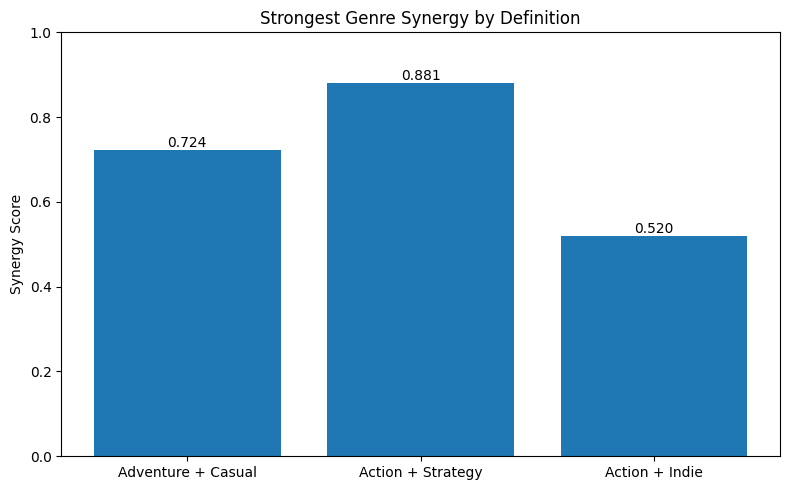

In [10]:
import matplotlib.pyplot as plt

labels = (
    results["genre_1"]
    + " + "
    + results["genre_2"]
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    results["score"],
)

ax.set_title(
    "Strongest Genre Synergy by Definition"
)
ax.set_ylabel("Synergy Score")
ax.set_ylim(0, 1)

for bar, value in zip(
    bars,
    results["score"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

## Conclusion

The strongest genre pair changes with the definition of operational synergy:

* Title-count similarity: **Adventure + Casual (0.724)**
* Owner-exposure similarity: **Action + Strategy (0.881)**
* Publisher overlap: **Action + Indie (0.520)**

The result therefore depends on how operational synergy is defined.
